# Notebook to test the beam_pattern.py tool and verify it works as expected

dsheen 2025-10-16

In [9]:
import os
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import astropy.units as u
import astropy.constants as const

In [2]:
from beam_pattern import BeamPattern

### initialize beam pattern tool

In [3]:
Beam_Response_Estimator = BeamPattern()

total directivity =  36.63595475628274
phistep = 5.0
thetastep = 0.25


### generate some nice arrays of values for test

do this as a cartesian path and then convert to theta/phi space

In [4]:
n=10
xangles = np.linspace(-15, 15, n)
yangles = np.linspace(0, -1, n)

points = np.array([xangles,yangles]).swapaxes(0,1)
thetas = np.sqrt(np.sum(np.power(points,2),axis=1))
phis = (np.arctan2(yangles, xangles) * 180 /np.pi)%360
print(thetas)
print(phis)

[15.         11.66719576  8.33629577  5.01109879  1.7249083   1.75682092
  5.04424865  8.36955093 11.7004801  15.03329638]
[180.         180.54565759 181.52752544 183.81407483 194.93141718
 341.56505118 352.40535663 354.66784112 355.64302499 356.18592517]


## test plot of azimuth slice

We want to verify this looks like our model when we've plotted it in the past (with the same orientation)
and indeed it is

In [5]:
plt.rcParams['figure.figsize'] = [8, 4.5]

n=100

xangles = np.linspace(-15, 15, n)
yangles = np.linspace(0, 0, n)

#points = np.array([xangles,yangles]).swapaxes(0,1)
#thetas = np.sqrt(np.sum(np.power(points,2),axis=1))
#phis = (np.arctan2(yangles, xangles) * 180 /np.pi)%360

thetas, phis = Beam_Response_Estimator.cartesian_angle_to_theta_phi(xangles, yangles)

linear_pattern = Beam_Response_Estimator.get_linear_total_directivities(thetas,phis)


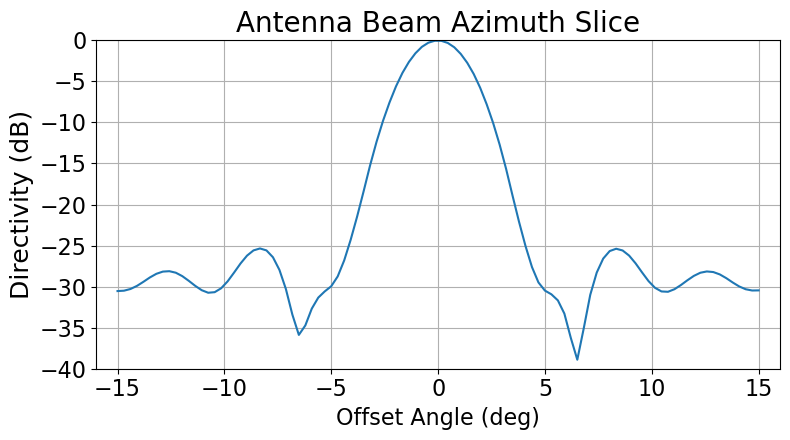

In [6]:
theta_signs = np.where(phis<180, 1, -1) #flip sign of theta is phi is past 180
thetavals = thetas * theta_signs #and apply back to theta
fig = plt.figure()

plt.plot(thetavals, 10*np.log10(linear_pattern))


plt.title('Antenna Beam Azimuth Slice', fontsize=20)
plt.ylabel('Directivity (dB)',fontsize=18)
plt.xlabel('Offset Angle (deg)',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim([-40,0])
plt.xlim([-16,16])
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
##### plot out grid of x and Y angles and make the thing give me the 
#full beam pattern so we can makes sure there aren't discontinuities

angle_range = [-100, 100]
extent = [angle_range[0],angle_range[1],angle_range[0],angle_range[1]]

xangles = np.linspace(angle_range[0], angle_range[1], 1500)
yangles = np.linspace(angle_range[0], angle_range[1], 1500)

x, y = np.meshgrid(xangles, yangles)

thetas, phis = Beam_Response_Estimator.cartesian_angle_to_theta_phi(x, y)
linear_pattern = Beam_Response_Estimator.get_linear_total_directivities(thetas,phis,normalized=False)

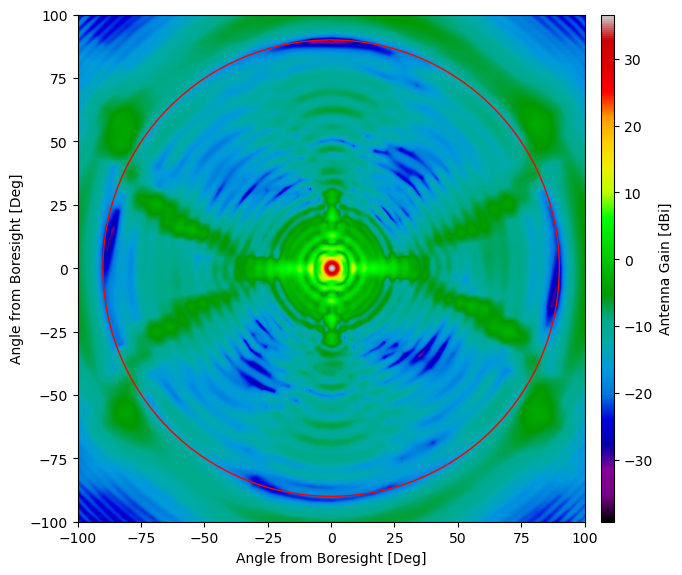

In [12]:
plt.rcParams['figure.figsize'] = [7, 7]

circle = plt.Circle((0, 0), 90, color='r', fill=False,)

fig = plt.figure()
ax = plt.gca()

im = ax.imshow(
    10*np.log10(linear_pattern[:,:,0])+36.63595475628274, #don't ask why this doesn't work as expected, I really don't know
    origin='lower',
    extent=extent,
    cmap='nipy_spectral')

ax.add_patch(circle)

ax.set_xlabel('Angle from Boresight [Deg]')
ax.set_ylabel('Angle from Boresight [Deg]')

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, aspect=0.5)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Antenna Gain [dBi]')

plt.show()